# 03 Purchase Intent Prediction

## Business Objective

Following the funnel and checkout analyses, the next objective is to develop a machine learning model capable of identifying high-intent users before they complete a purchase.

Such a model can support personalized recommendations, targeted promotions, and proactive interventions to improve conversion rates.

In [202]:
from pathlib import Path
import sys
import joblib

# Project root
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [203]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [204]:
import pandas as pd
import numpy as np

from src.services import (
    load_purchase_prediction
)

In [205]:
df_prediction = load_purchase_prediction()
display(df_prediction.head())

,session_duration_sec,total_events,total_engagement_time,pageviews,unique_pages,item_views,searches,add_to_cart,begin_checkout,add_shipping_info,...,operating_system,country,session_source,acquisition_channel,session_medium,session_campaign,engagement_per_event,item_view_rate,checkout_ratio,purchased
0,40,19,15856,6,4,0,0,0,2,1,...,Android,United States,NaN,Unknown,NaN,NaN,834.526316,0.000000,0.0,False
1,33,15,22006,3,4,1,0,1,2,1,...,Web,United States,NaN,Unknown,NaN,NaN,1467.066667,0.333333,2.0,False
2,40,16,21801,3,4,1,0,2,2,1,...,Web,Taiwan,NaN,Unknown,NaN,NaN,1362.562500,0.333333,1.0,False
3,1300,171,1080301,48,18,17,0,6,12,6,...,Web,United States,NaN,Unknown,NaN,NaN,6317.549708,0.354167,2.0,True
4,145,28,128770,10,7,0,0,0,1,1,...,Web,United States,(data deleted),Unknown,(data deleted),(data deleted),4598.928571,0.000000,0.0,False


In [206]:
display(df_prediction.shape)
display(df_prediction.info())
display(df_prediction.describe())

(11088, 22)

<class 'pandas.DataFrame'>
RangeIndex: 11088 entries, 0 to 11087
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   session_duration_sec   11088 non-null  Int64  
 1   total_events           11088 non-null  Int64  
 2   total_engagement_time  11088 non-null  Int64  
 3   pageviews              11088 non-null  Int64  
 4   unique_pages           11088 non-null  Int64  
 5   item_views             11088 non-null  Int64  
 6   searches               11088 non-null  Int64  
 7   add_to_cart            11088 non-null  Int64  
 8   begin_checkout         11088 non-null  Int64  
 9   add_shipping_info      11088 non-null  Int64  
 10  add_payment_info       11088 non-null  Int64  
 11  device_category        11088 non-null  str    
 12  operating_system       11088 non-null  str    
 13  country                11088 non-null  str    
 14  session_source         11084 non-null  str    
 15  acquisition_c

None

,session_duration_sec,total_events,total_engagement_time,pageviews,unique_pages,item_views,searches,add_to_cart,begin_checkout,add_shipping_info,add_payment_info,engagement_per_event,item_view_rate,checkout_ratio
count,11088.0,11088.0,11088.0,11088.0,11088.0,11088.0,11088.0,11088.0,11088.0,11088.0,11088.0,11088.000000,11088.000000,11088.000000
mean,2990.949315,105.390602,678251.538781,33.479798,21.43281,14.212482,0.493146,2.691739,3.4954,1.778589,1.253337,6598.509767,0.363545,0.967510
std,27721.315637,90.208615,657245.911793,32.870532,25.765796,17.876301,1.448103,5.492801,3.417385,1.47403,1.641478,4626.283399,0.237474,1.818545
min,0.0,5.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.000000,0.000000
25%,407.0,42.0,224678.0,12.0,8.0,3.0,0.0,0.0,2.0,1.0,0.0,3514.380028,0.200000,0.000000
50%,1015.5,71.0,514288.0,21.0,12.0,6.0,0.0,1.0,2.0,1.0,1.0,5892.938070,0.333333,0.200000
75%,1732.0,132.0,898742.75,38.0,19.0,18.0,0.0,3.0,4.0,2.0,2.0,8343.493125,0.482143,1.000000
max,2523362.0,942.0,9921347.0,303.0,171.0,319.0,51.0,74.0,54.0,22.0,23.0,239086.400000,2.703704,42.000000


In [207]:
df_prediction.isna().sum().sort_values(ascending=False)

session_campaign         4
session_medium           4
session_source           4
session_duration_sec     0
total_events             0
checkout_ratio           0
item_view_rate           0
engagement_per_event     0
acquisition_channel      0
country                  0
operating_system         0
device_category          0
add_payment_info         0
add_shipping_info        0
begin_checkout           0
add_to_cart              0
searches                 0
item_views               0
unique_pages             0
pageviews                0
total_engagement_time    0
purchased                0
dtype: int64

In [208]:
df_prediction["session_source"] = df_prediction["session_source"].fillna("Unknown")
df_prediction["session_medium"] = df_prediction["session_medium"].fillna("Unknown")
df_prediction["session_campaign"] = df_prediction["session_campaign"].fillna("Unknown")

In [209]:
df_prediction.isna().sum().sort_values(ascending=False)

session_duration_sec     0
total_events             0
checkout_ratio           0
item_view_rate           0
engagement_per_event     0
session_campaign         0
session_medium           0
acquisition_channel      0
session_source           0
country                  0
operating_system         0
device_category          0
add_payment_info         0
add_shipping_info        0
begin_checkout           0
add_to_cart              0
searches                 0
item_views               0
unique_pages             0
pageviews                0
total_engagement_time    0
purchased                0
dtype: int64

In [210]:
df_prediction.duplicated().sum()

np.int64(0)

In [211]:
df_prediction["purchased"].value_counts(normalize=True)

purchased
False    0.563312
True     0.436688
Name: proportion, dtype: Float64

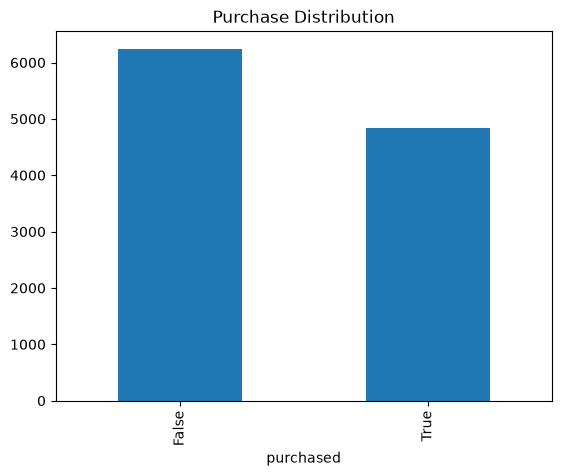

In [212]:
import matplotlib.pyplot as plt

df_prediction["purchased"].value_counts().plot(kind="bar")

plt.title("Purchase Distribution")
plt.show()

<Figure size 500x300 with 0 Axes>

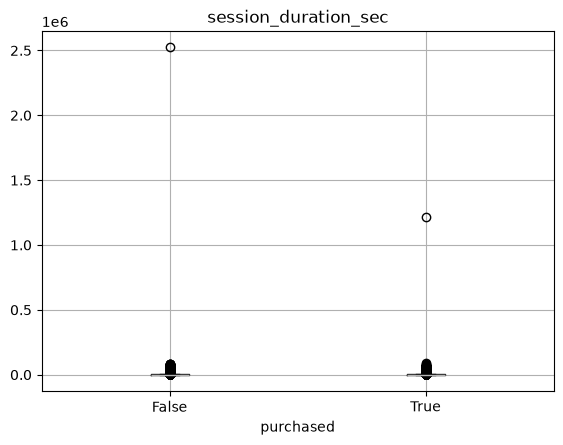

<Figure size 500x300 with 0 Axes>

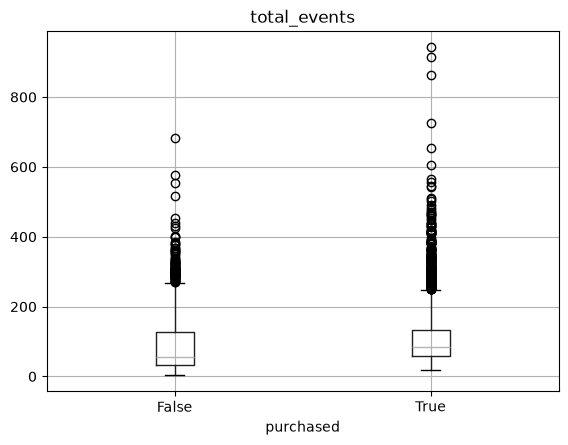

<Figure size 500x300 with 0 Axes>

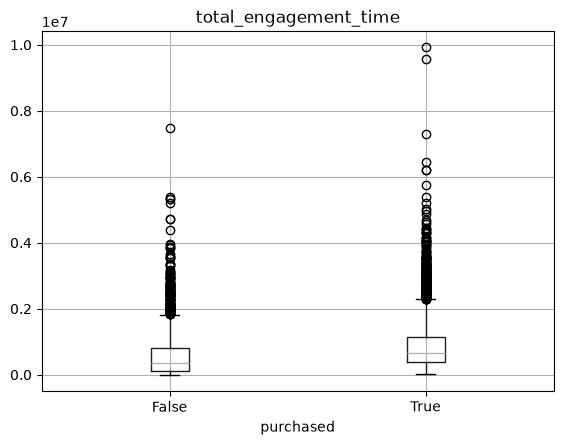

<Figure size 500x300 with 0 Axes>

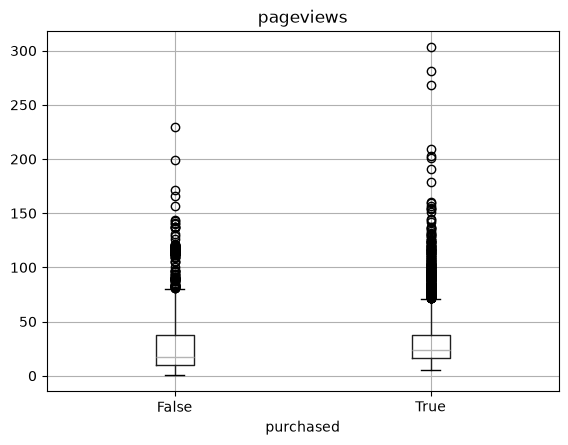

<Figure size 500x300 with 0 Axes>

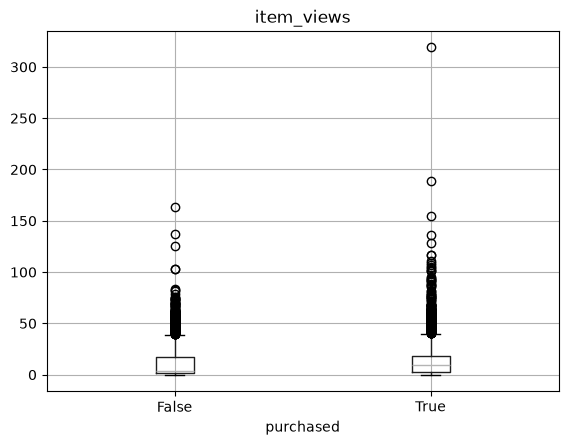

<Figure size 500x300 with 0 Axes>

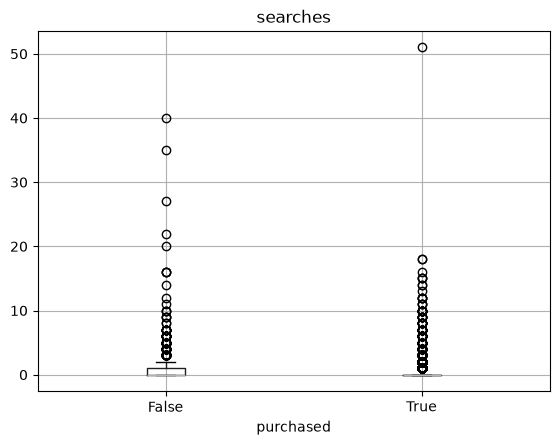

<Figure size 500x300 with 0 Axes>

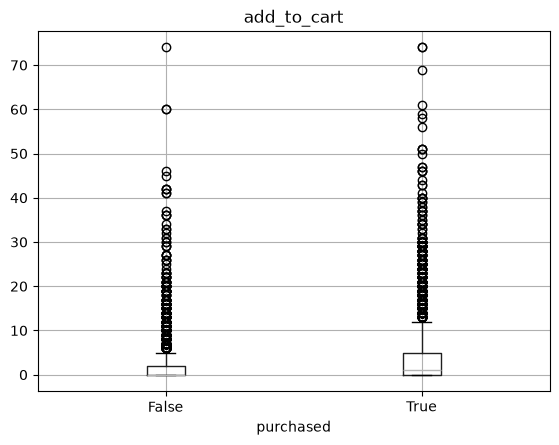

<Figure size 500x300 with 0 Axes>

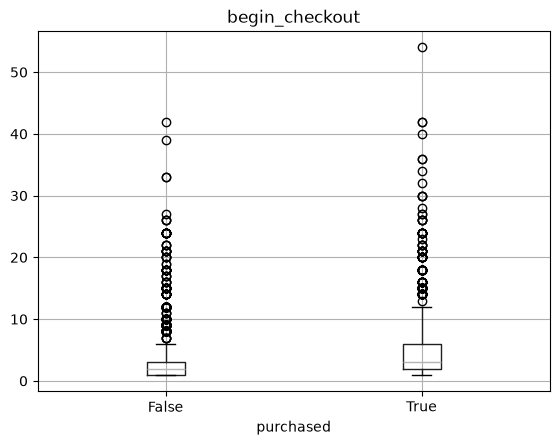

<Figure size 500x300 with 0 Axes>

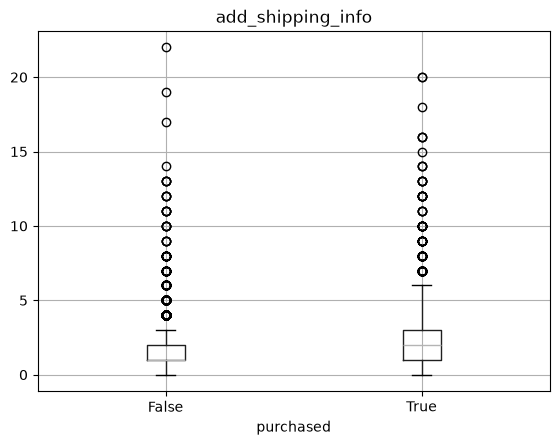

<Figure size 500x300 with 0 Axes>

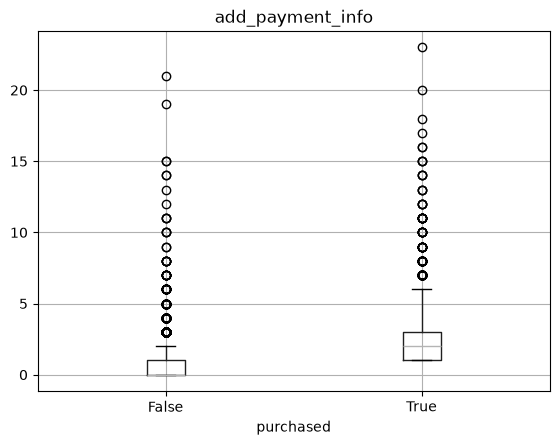

In [213]:
numerical_features = [
    "session_duration_sec",
    "total_events",
    "total_engagement_time",
    "pageviews",
    "item_views",
    "searches",
    "add_to_cart",
    "begin_checkout",
    "add_shipping_info",
    "add_payment_info"
]

for col in numerical_features:
    plt.figure(figsize=(5,3))
    df_prediction.boxplot(column=col, by="purchased")
    plt.title(col)
    plt.suptitle("")
    plt.show()

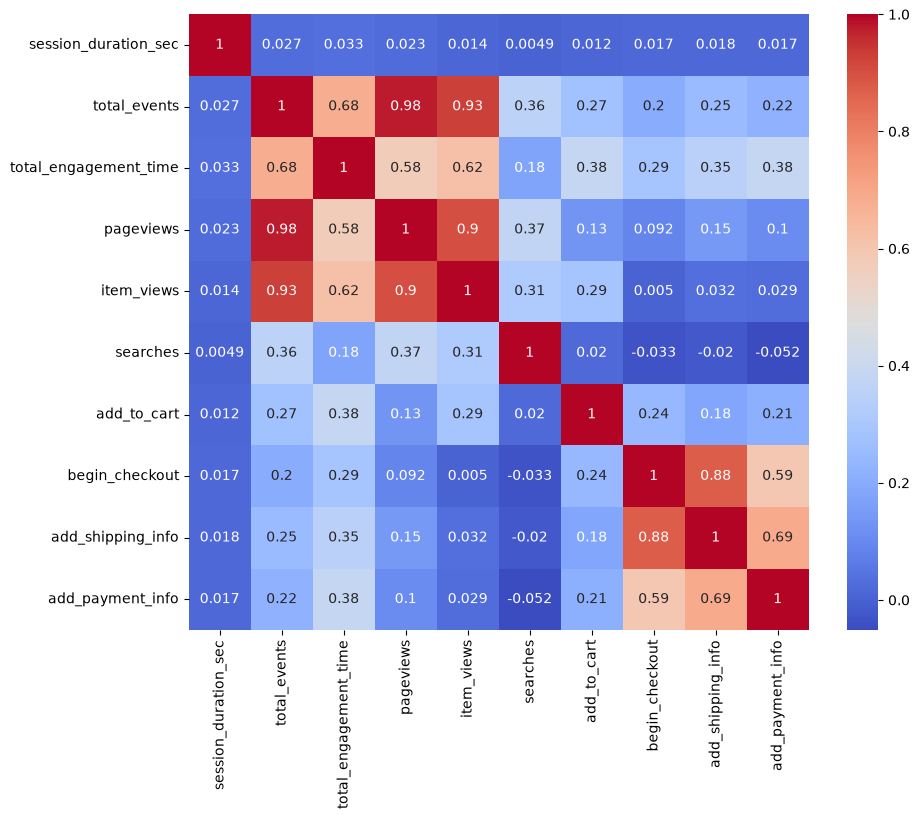

In [214]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    df_prediction[numerical_features].corr(),
    cmap="coolwarm",
    annot=True
)

plt.show()

In [215]:
pd.crosstab(
    df_prediction["device_category"],
    df_prediction["purchased"],
    normalize="index"
)

purchased,False,True
device_category,,
desktop,0.569168,0.430832
mobile,0.554535,0.445465
tablet,0.570833,0.429167


## Feature Engineering

Three additional behavioural features were engineered to better capture user engagement and purchase intent:

- Engagement per Event
- Item View Rate
- Checkout Ratio

These derived features provide more informative behavioural signals than the original event counts alone.

In [216]:
df_prediction["engagement_per_event"] = (
    df_prediction["total_engagement_time"] /
    df_prediction["total_events"]
)

df_prediction["item_view_rate"] = (
    df_prediction["item_views"] /
    df_prediction["pageviews"]
)

#df_prediction["checkout_progress"] = (
#    df_prediction["begin_checkout"]
#    + df_prediction["add_shipping_info"]
#   + df_prediction["add_payment_info"]
#)

df_prediction["checkout_ratio"] = (
    df_prediction["begin_checkout"] /
    (df_prediction["add_to_cart"] + 1)
)

## Model Development

Raw Features
      ↓
Train/Test Split
      ↓
Preprocessing
(StandardScaler + OneHotEncoder)
      ↓
Logistic Regression
      ↓
Random Forest
      ↓
Hyperparameter Tuning
      ↓
XGBoost

In [217]:
from sklearn.model_selection import train_test_split

X = df_prediction.drop(columns=[
    "purchased",
    "add_shipping_info",
    "add_payment_info"
])

X = X.drop(columns=[
    "session_source",
    "session_medium",
    "session_campaign"
])

y = df_prediction["purchased"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [218]:
categorical_features = [
    "device_category",
    "operating_system",
    "country",
    "acquisition_channel"
]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

In [219]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [220]:
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                random_state=42,
                max_iter=1000
            )
        )
    ]
)

In [224]:
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['session_duration_sec','total_events','total_engagement_time',..., 'engagement_per_event','item_view_rate','checkout_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default

In [225]:
joblib.dump(
    baseline_model,
    "models/baseline_model.pkl"
)

['models/baseline_model.pkl']

In [226]:
y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

In [227]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.71      0.78      0.75      1227
         1.0       0.69      0.61      0.65       991

    accuracy                           0.71      2218
   macro avg       0.70      0.70      0.70      2218
weighted avg       0.70      0.71      0.70      2218



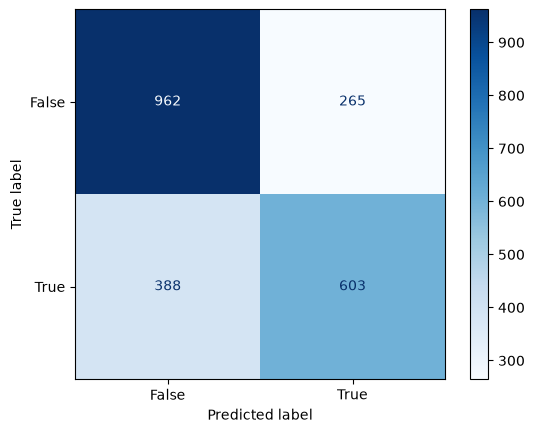

In [228]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

In [229]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.8024


In [230]:
from sklearn.ensemble import RandomForestClassifier

In [231]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

In [232]:
joblib.dump(
    rf_model,
    "models/rf_model.pkl"
)

['models/rf_model.pkl']

In [233]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

         0.0       0.77      0.72      0.75      1227
         1.0       0.68      0.73      0.71       991

    accuracy                           0.73      2218
   macro avg       0.73      0.73      0.73      2218
weighted avg       0.73      0.73      0.73      2218



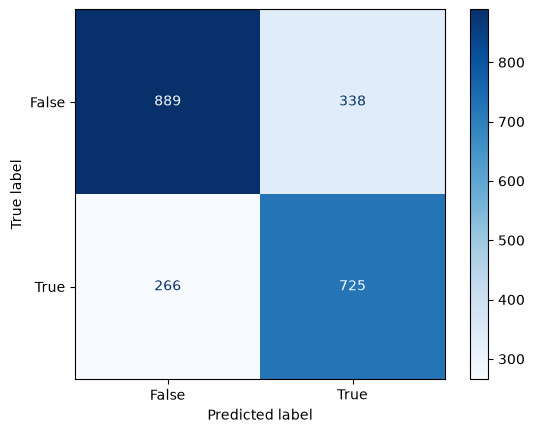

In [234]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    cmap="Blues"
)

In [235]:
rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

print(f"ROC-AUC: {rf_auc:.4f}")

ROC-AUC: 0.8047


In [236]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision":[
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall":[
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1":[
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC-AUC":[
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.705591,0.694700,0.608476,0.648736,0.802416
1,Random Forest,0.727683,0.682032,0.731584,0.705940,0.804691


In [237]:
param_dist = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [5, 10, 20, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"]
}

In [238]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=rf_model,

    param_distributions=param_dist,

    n_iter=20,

    cv=5,

    scoring="roc_auc",

    random_state=42,

    n_jobs=-1,

    verbose=1
)

In [239]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__max_depth': [5, 10, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best esti

In [240]:
print(random_search.best_params_)
print(random_search.best_score_)

{'classifier__n_estimators': 100, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'sqrt', 'classifier__max_depth': None}
0.8133080395936039


In [241]:
best_rf = random_search.best_estimator_
best_pred = best_rf.predict(X_test)

best_prob = best_rf.predict_proba(X_test)[:,1]

In [242]:
joblib.dump(
    best_rf,
    "models/tuned_rf_model.pkl"
)

['models/tuned_rf_model.pkl']

In [243]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)

print(classification_report(
    y_test,
    best_pred
))

print(
    f"ROC-AUC: {roc_auc_score(y_test,best_prob):.4f}"
)

              precision    recall  f1-score   support

         0.0       0.79      0.72      0.75      1227
         1.0       0.69      0.76      0.72       991

    accuracy                           0.74      2218
   macro avg       0.74      0.74      0.74      2218
weighted avg       0.74      0.74      0.74      2218

ROC-AUC: 0.8110


In [244]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,best_pred)
    ],

    "Precision":[
        precision_score(y_test,y_pred),
        precision_score(y_test,rf_pred),
        precision_score(y_test,best_pred)
    ],

    "Recall":[
        recall_score(y_test,y_pred),
        recall_score(y_test,rf_pred),
        recall_score(y_test,best_pred)
    ],

    "F1":[
        f1_score(y_test,y_pred),
        f1_score(y_test,rf_pred),
        f1_score(y_test,best_pred)
    ],

    "ROC-AUC":[
        roc_auc_score(y_test,y_prob),
        roc_auc_score(y_test,rf_prob),
        roc_auc_score(y_test,best_prob)
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.705591,0.694700,0.608476,0.648736,0.802416
1,Random Forest,0.727683,0.682032,0.731584,0.705940,0.804691
2,Tuned Random Forest,0.737151,0.685792,0.759839,0.720919,0.811029


In [245]:
rf = best_rf.named_steps["classifier"]

feature_names = best_rf.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

importance = (
    importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

importance.head(20)

,Feature,Importance
9,num__engagement_per_event,0.127408
2,num__total_engagement_time,0.114073
4,num__unique_pages,0.092359
0,num__session_duration_sec,0.088317
1,num__total_events,0.080527
3,num__pageviews,0.072261
10,num__item_view_rate,0.059026
5,num__item_views,0.057220
8,num__begin_checkout,0.041491
7,num__add_to_cart,0.038699


In [246]:
importance.to_csv(
    "outputs/feature_importance.csv",
    index=False
)

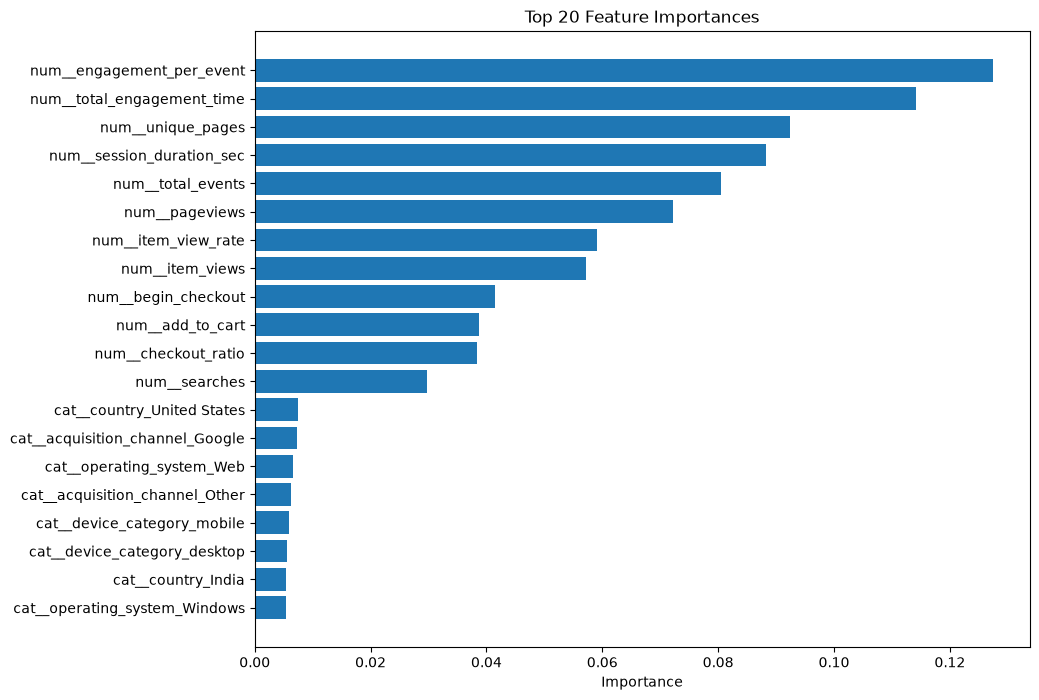

In [247]:
import matplotlib.pyplot as plt

top20 = importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Feature Importances")

plt.xlabel("Importance")

plt.show()

In [248]:
from xgboost import XGBClassifier

In [249]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

In [250]:
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [251]:
joblib.dump(
    xgb_model,
    "models/xgb_model.pkl"
)

['models/xgb_model.pkl']

In [252]:
print(classification_report(
    y_test,
    xgb_pred
))
print(
    f"ROC-AUC: {roc_auc_score(y_test, xgb_prob):.4f}"
)

              precision    recall  f1-score   support

         0.0       0.77      0.74      0.75      1227
         1.0       0.69      0.73      0.71       991

    accuracy                           0.73      2218
   macro avg       0.73      0.73      0.73      2218
weighted avg       0.73      0.73      0.73      2218

ROC-AUC: 0.8171


In [253]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, best_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, best_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, best_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, best_pred),
        f1_score(y_test, xgb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, best_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

comparison.sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
3,XGBoost,0.733093,0.691643,0.726539,0.708661,0.817067
2,Tuned Random Forest,0.737151,0.685792,0.759839,0.720919,0.811029
1,Random Forest,0.727683,0.682032,0.731584,0.705940,0.804691
0,Logistic Regression,0.705591,0.694700,0.608476,0.648736,0.802416


In [254]:
comparison.to_csv(
    "outputs/model_comparison.csv",
    index=False
)

## Conclusion

The Tuned Random Forest achieved the best overall predictive performance while maintaining a strong balance between precision and recall.

Behavioural engagement features consistently outperformed demographic and device-related variables, indicating that user interactions provide the strongest indicators of purchase intent.

These findings demonstrate that purchase intent can be predicted with meaningful accuracy before conversion occurs, enabling future applications such as personalized recommendations, remarketing campaigns, and real-time intervention strategies.